# Métodos de Clustering
**Aprendizaje de Máquina - CEIA - FIUBA**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pred_strength import prediction_strength_cross_validation
from sklearn.preprocessing import StandardScaler

## K-means

K-Means es uno de los algoritmos de aprendizaje automático no supervisado más utilizados para el agrupamiento o clustering de datos. Su objetivo es dividir un conjunto de datos en grupos o clústeres de manera que los elementos dentro de un mismo clúster sean similares entre sí y, al mismo tiempo, diferentes de los elementos en otros clústeres. Este algoritmo es útil para descubrir patrones y estructuras en los datos sin necesidad de etiquetas o categorías predefinidas.

Para este tipo de algoritmo vamos a usar el siguiente dataset [mall_customers.csv](https://www.kaggle.com/datasets/shwetabh123/mall-customers). Este dataset posee datos de clientes que asisten a un Mall, edad, ingresos anuales y un score dado el nivel de gastos en el Mall. Se busca establecer diferente tipo de clientes que nos permitan establecer campañas de marketing de préstamos más personalizadas.

In [2]:
# Cargamos los datos con pandas
df = pd.read_csv("mall_customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

Para este problema, no vamos a usar la edad para establecer tipos de clientes. Nos vamos a quedar con **Annual Income (k$)** y **Spending Score (1-100)**

In [5]:
X = df.iloc[:, [3,4]].values
X = X.astype('float64') 

Los métodos de clustering usan distancia, por lo que es apropiado escalar en similar magnitud a los atributos.

In [6]:
# Los metodos de clustering usan distancia, por lo que es apropiado escalar en similar 
# magnitud a los atributos.
scaler = StandardScaler()
scaled_x = scaler.fit_transform(X)

Un problema que tenemos es que K-means necesita de entrada el número de clusters que queremos calcular. Pero en este problema no tenemos idea de cuántos tipos de clientes tenemos. Por lo que necesitamos establecer de alguna forma este número. Una forma de hacerlo usando la *Suma de Cuadrados Intracluster* (WCSS) y ver cual es el número que cluster que minimiza este valor.

Este procedimiento es algo parecido a la validación cruzada en aprendizaje supervisado.

Vamos a usar de sklearn el modelo [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

In [7]:
from sklearn.cluster import KMeans

In [8]:
# Vamos a calcular diferentes modelos de K-means, cambiando la cantidad de cluster en
# cada iteración
wcss = []
for i in range(1, 20):
    kmeans = KMeans(n_clusters = i,       
                    init = "k-means++",     # Esta forma busca una inicialización que 
                                            # converga más rapido que incializar al azar
                    max_iter = 300,         # El número máximo de iteraciones
                    n_init = 10,            # Cuántas veces repite la ejecución del 
                                            # algoritmo hasta que se quede con el mejor
                                            # caso
                    random_state = 42)
    kmeans.fit(scaled_x)
    wcss.append(kmeans.inertia_)            # SKlearn le llama inercia a WCSS

Ahora grafiquemos los resultados

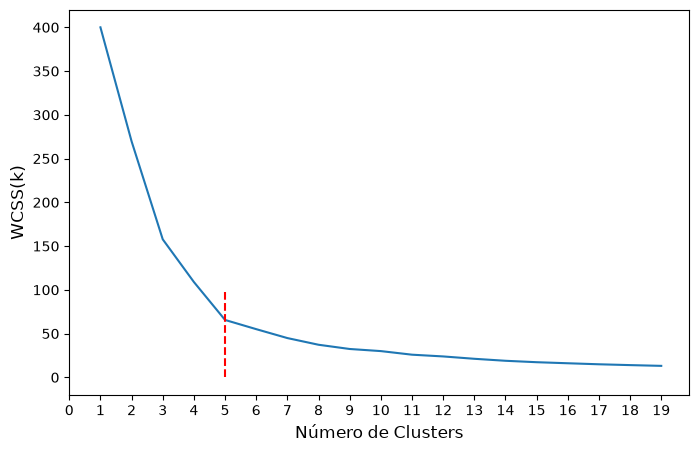

In [9]:
plt.figure(figsize=(8, 5)) 
plt.plot(range(1,20), wcss)
plt.plot([5, 5], [0, 100], color="r", linestyle="--")
plt.xlabel("Número de Clusters", fontsize=12)
plt.ylabel("WCSS(k)", fontsize=12)
plt.xticks(np.arange(0, 20, step=1))
plt.show()

Lo que tenemos que ver acá, medio a ojo, es cual el mínimo número de clusters en donde WCSS(k) empieza a estabilizarse. Este método se llama el **método del codo**.

Otra métrica que podemos ver es el score de la silueta. Este score mide, para una observación, qué tan similar es en su propio cluster (cohesión) comparado con otros clusters (separación). Para cada observación, el valor va de -1 a 1, donde un valor alto indica que la observación coincide bien con su propio grupo y no con los grupos vecinos.

Este puntaje se puede usar con cualquier medida de distancia.


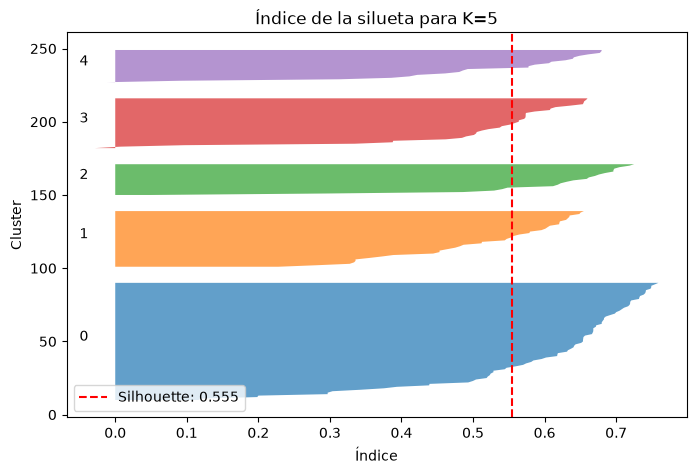

In [10]:
from sklearn.metrics import silhouette_samples, silhouette_score

SELECTED_K = 5

kmeans = KMeans(n_clusters=SELECTED_K, init="k-means++", max_iter=300, n_init=10, 
    random_state=42)

y = kmeans.fit_predict(scaled_x)
labels = kmeans.labels_

# Calculamos el índice de silueta
score = silhouette_score(scaled_x, y, metric="euclidean") # Usamos distancia euclidiana

silhouette_vals = silhouette_samples(scaled_x, y)

plt.figure(figsize=(8,5))
y_lower = 10

for i in range(SELECTED_K):
    vals = silhouette_vals[y == i]
    vals.sort()
    size = len(vals)
    y_upper = y_lower + size

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
    plt.text(-0.05, (y_lower + y_upper) / 2, str(i))
    y_lower = y_upper + 10  # espacio entre clusters

# Línea vertical con el silhouette promedio
plt.axvline(score, color='red', linestyle='--', label=f"Silhouette: {score:.3f}")

plt.title("Índice de la silueta para K=5")
plt.xlabel("Índice")
plt.ylabel("Cluster")
plt.legend(loc="lower left")
plt.show()



El puntaje que vamos a calcular ahora es la media de todas las observaciones.

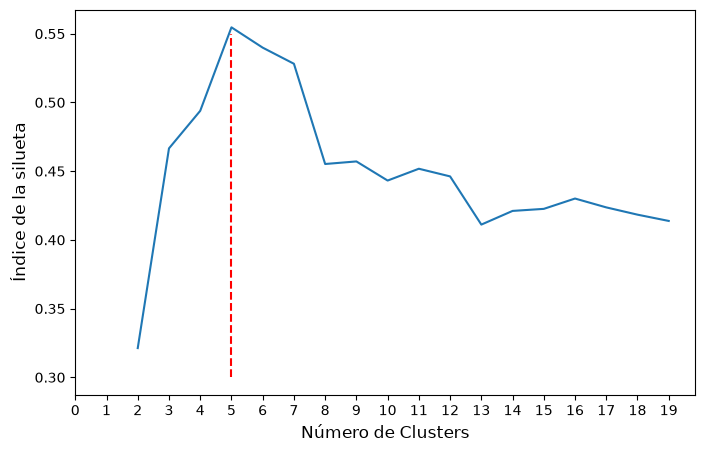

In [11]:
# Vamos a calcular diferentes modelos de K-means, cambiando la cantidad de clusters en 
# cada iteración
silhouette_list = []
for i in range(2, 20):
    kmeans = KMeans(n_clusters=i, init="k-means++", max_iter=300, n_init=10, 
        random_state=42)

    y = kmeans.fit_predict(scaled_x)

    # Calculamos el índice de silueta
    silhouette_list.append(silhouette_score(scaled_x, y, metric="euclidean"))           

plt.figure(figsize=(8, 5)) 
plt.plot(range(2,20), silhouette_list)
plt.plot([5, 5], [0.3, 0.55], color="r", linestyle="--")
plt.xlabel("Número de Clusters", fontsize=12)
plt.ylabel("Índice de la silueta", fontsize=12)
plt.xticks(np.arange(0, 20, step=1))
plt.show()

Lo que vemos aquí es que el score de silueta promedio es mayor en k=5.

Por último, validemos con una tercera métrica usando la métrica de fuerza de predicción, haciendo una validación cruzada de 5 folds y repitiendo esto 30 veces de 2 a 19 cantidad de clusters.

In [12]:
results = np.zeros((18, 2))
for i in range(2, 20):
    
    loop_result = np.zeros((30, 2))

    for rep in range(30):

        # Y hacemos validación cruzada de 5-Folds.
        model = KMeans(n_clusters=i, init="k-means++", max_iter=300, n_init=10, 
                    random_state=42)
  
        pred_stre_mean, pred_stre_std = prediction_strength_cross_validation(
            scaled_x, model, cross_validation_split=5)
        
        loop_result[rep, 0] = pred_stre_mean
        loop_result[rep, 1] = pred_stre_std

    results[i-2, 0] = np.mean(loop_result[:, 0])
    results[i-2, 1] = np.mean(loop_result[:, 1])

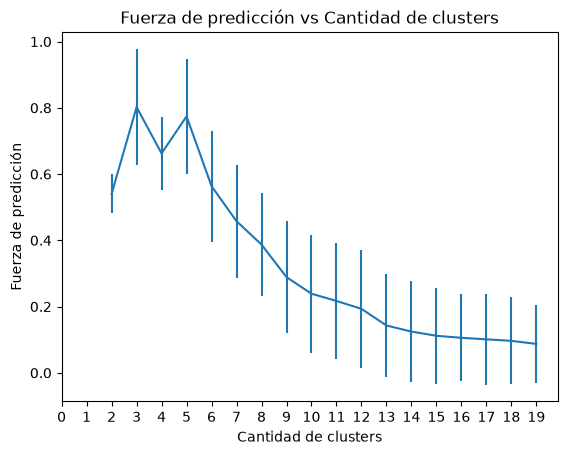

In [13]:
plt.errorbar([*range(2, 20)], results[:, 0], yerr=results[:, 1])
plt.xlabel("Cantidad de clusters")
plt.ylabel("Fuerza de predicción")
plt.title("Fuerza de predicción vs Cantidad de clusters")
plt.xticks(np.arange(0, 20, step=1))
plt.show()

Acá vemos que 3 y 5 clusters dan los mejores resultados, que son justamente donde ocurren los cambios más grandes en el método de los codos, y en el puntaje de silueta el mayor caso es 5.

Dado todos los resultados, vamos a elegir K=5

In [14]:
# Aplicar el método de k-means para segmentar el data set
kmeans = KMeans(n_clusters = 5, init="k-means++", max_iter = 300, n_init = 10,
    random_state = 0)

In [15]:
y_kmeans = kmeans.fit_predict(scaled_x)

Si ahora quisieramos usar a esta clusterización como información para nuestro dataframe, se puede hacer:

In [16]:
df['Cluster (kmeans)'] = y_kmeans
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster (kmeans)
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


O inclusive guardar el nombre de categorias que elegimos

In [17]:
categories = {
    0: "Standard",
    1: "Spender",
    2: "Conservative",
    3: "Cautious",
    4: "Careless"
}

df["Client category (kmeans)"] = df['Cluster (kmeans)'].replace(categories)

In [18]:
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster (kmeans),Client category (kmeans)
0,1,Male,19,15,39,3,Cautious
1,2,Male,21,15,81,4,Careless
2,3,Female,20,16,6,3,Cautious
3,4,Female,23,16,77,4,Careless
4,5,Female,31,17,40,3,Cautious
5,6,Female,22,17,76,4,Careless
6,7,Female,35,18,6,3,Cautious
7,8,Female,23,18,94,4,Careless
8,9,Male,64,19,3,3,Cautious
9,10,Female,30,19,72,4,Careless


Ahora visualizamos a los clusters

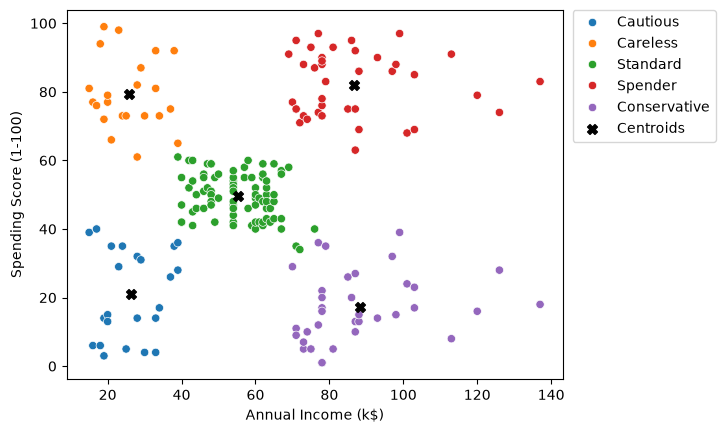

In [19]:
ax = sns.scatterplot(data=df, 
                x="Annual Income (k$)", 
                y="Spending Score (1-100)", 
                hue="Client category (kmeans)")

re_scaled_centroids = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(re_scaled_centroids[:, 0], re_scaled_centroids[:, 1], s=50, c='black',
    marker='X', label='Centroids')
                
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0);

## Gaussian Mixture Model

K-means es simple y relativamente fácil de entender, pero su simplicidad plantea desafíos prácticos en su aplicación. La naturaleza no probabilística de K-means y el uso de simplemente una distancia desde el centro del grupo para asignar la membresía del grupo conduce a un rendimiento deficiente en muchas situaciones del mundo real. 

Un **Gaussian Mixture Model** intenta encontrar una mezcla de distribuciones de probabilidad gaussianas multidimensionales que modelen mejor cualquier conjunto de datos de entrada. Veamos entonces a **Gaussian Mixture Model**, que pueden verse como una extensión de las ideas detrás de K-means.

Vamos a usar de sklearn el modelo [GaussianMixture](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)

In [20]:
from sklearn.mixture import GaussianMixture

In [21]:
gmm = GaussianMixture(n_components=5, # Debemos definir el número de distribuciones a 
                                      # definir
                      covariance_type='full', # Es como vamos a calcular la covarianza.
                                              # El caso elegido es el más ineficiente 
                                              # pero da mejores resultados.
                      random_state=0)

In [22]:
# Observese que no es necesario escalar, aunque es recomendable
gmm = gmm.fit(X)

Una gran ventaja de este método es que podemos obtener las probabilidades de pertenece a un cluster.

In [23]:
y_gmm = gmm.predict(X)
y_probs = gmm.predict_proba(X)

In [24]:
y_probs[:5, :]

array([[1.57646362e-05, 1.87994402e-08, 5.19973770e-08, 9.99032168e-01,
        9.51996351e-04],
       [1.62759672e-05, 1.89593733e-04, 4.20852354e-23, 3.94117874e-06,
        9.99790189e-01],
       [2.21099960e-19, 9.52352829e-19, 1.86219457e-04, 9.99813781e-01,
        1.22525998e-12],
       [1.05436234e-04, 1.80084205e-04, 3.79258615e-21, 2.07213221e-05,
        9.99693758e-01],
       [6.47143510e-05, 3.84242794e-08, 4.75683328e-08, 9.98378558e-01,
        1.55664181e-03]])

In [25]:
from matplotlib.patches import Ellipse


def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()
    
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        uu, s, vvt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(uu[1, 0], uu[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Draw the Ellipse
    for nsig in range(1, 4):
        a = position
        b = nsig * width
        c = nsig * height
        d = angle
        ax.add_patch(Ellipse(a, b, c, angle=d, **kwargs))

In [26]:
df['Cluster (gmm)'] = y_gmm
df["Client category (gmm)"] = df['Cluster (gmm)'].replace(categories)
df["Gmm size"] =  y_probs.max(1) ** 2

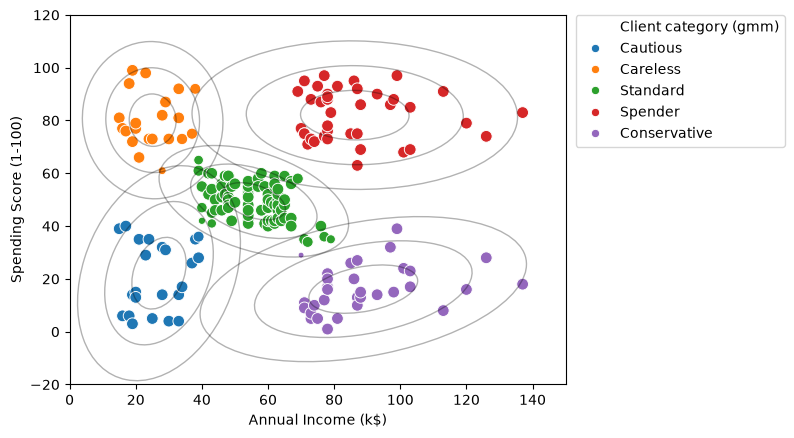

In [27]:
ax = sns.scatterplot(data=df, 
                     x="Annual Income (k$)", 
                     y="Spending Score (1-100)", 
                     hue="Client category (gmm)", 
                     size="Gmm size",
                     legend="brief")

h, ll = ax.get_legend_handles_labels()
index_size = ll.index("Gmm size")
ax.legend(h[:index_size], ll[:index_size], 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left',          
          borderaxespad=0)

for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
    draw_ellipse(pos, covar, alpha=0.3, edgecolor="k", facecolor="none", axes=ax)
    
ax.set_xlim(0, 150)
ax.set_ylim(-20, 120);

Veamos si **fuerza de predicción** nos dice cuántos clusters es el óptimo para este caso.

In [28]:
results = np.zeros((18, 2))
for i in range(2, 20):

    loop_result = np.zeros((30, 2))

    for rep in range(30):
        
        # Y hacemos validación cruzada de 5-Folds.
        model = GaussianMixture(n_components=i, covariance_type='full', 
            random_state = 42)
        
        pred_stre_mean, pred_stre_std = prediction_strength_cross_validation(scaled_x,
            model, cross_validation_split=5, type_model="mixture")
        
        loop_result[rep, 0] = pred_stre_mean
        loop_result[rep, 1] = pred_stre_std

    results[i-2, 0] = np.mean(loop_result[:, 0])
    results[i-2, 1] = np.mean(loop_result[:, 1])

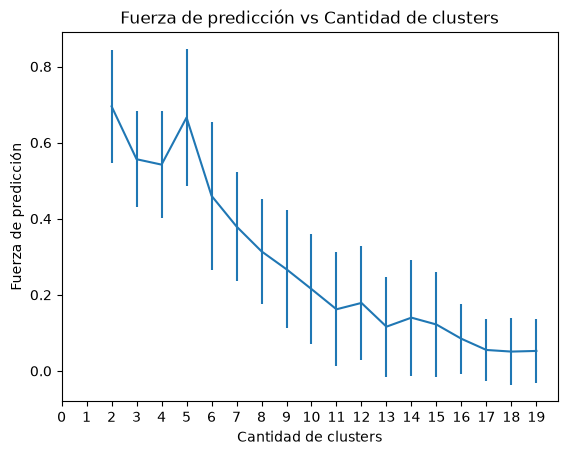

In [29]:
plt.errorbar([*range(2, 20)], results[:, 0], yerr=results[:, 1])
plt.xlabel("Cantidad de clusters")
plt.ylabel("Fuerza de predicción")
plt.title("Fuerza de predicción vs Cantidad de clusters")
plt.xticks(np.arange(0, 20, step=1))
plt.show()

Aqui se observa como 5 clusters es claro el que mejor valor nos da de fuerza de predicción en GMM

## Hierarchical clustering

El clustering jerárquico es un algoritmo de aprendizaje automático no supervisado utilizado para agrupar datos en función de su similitud.
Su objetivo es organizar las observaciones jerárquicamente en una estructura tipo árbol, donde los elementos más parecidos se agrupan primero y los menos similares se combinan en niveles superiores. Este método permite visualizar las relaciones entre los datos mediante un dendrograma y **explorar diferentes números de clusters sin necesidad de definirlos previamente**, lo que facilita la interpretación y el descubrimiento de patrones en los datos.

Para ver cómo funciona, vamos a generar unos datos sintéticos.

In [30]:
import numpy as np
from sklearn.datasets import make_blobs

# Generamos datos sintéticos con ruido y clusters solapados
X_blobs, y_blobs = make_blobs(
    n_samples=150,
    centers=[(0,0), (2,2), (5,1)],  # centros no simétricos
    cluster_std=[1.0, 1.2, 1.8],    # distinta dispersión por grupo
    random_state=42
)

# Agregamos algunos puntos de ruido aleatorio
noise = np.random.uniform(low=-3, high=8, size=(15, 2))
X_blobs = np.vstack([X_blobs, noise])


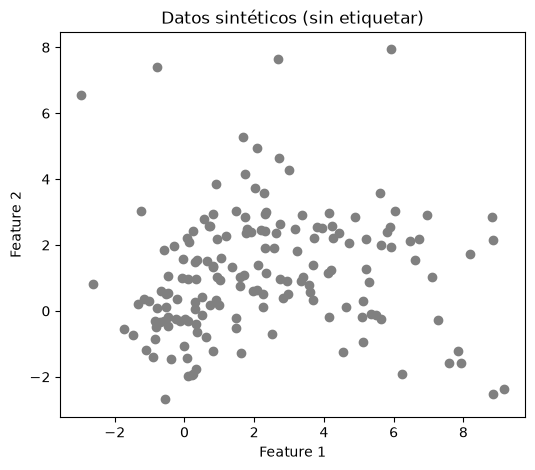

In [31]:
plt.figure(figsize=(6, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c='gray')
plt.title("Datos sintéticos (sin etiquetar)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Creamos la estructura jerárquica de clusters usando las funciones para [Hierarchical Clustering](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html) de Scipy.

Por defecto, Scipy utiliza la distancia euclidiana y el método de linkage `single`.

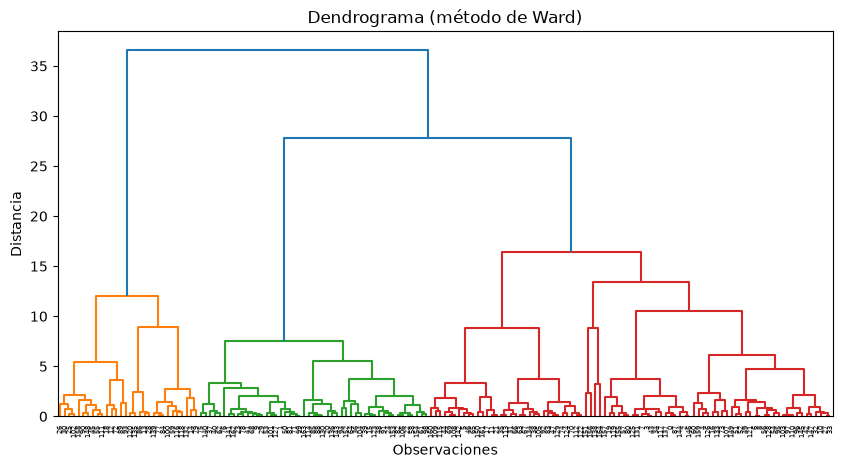

In [32]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

# Calculamos el linkage
Z = linkage(X_blobs, method='ward')

# Dibujamos el dendrograma
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrograma (método de Ward)")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()


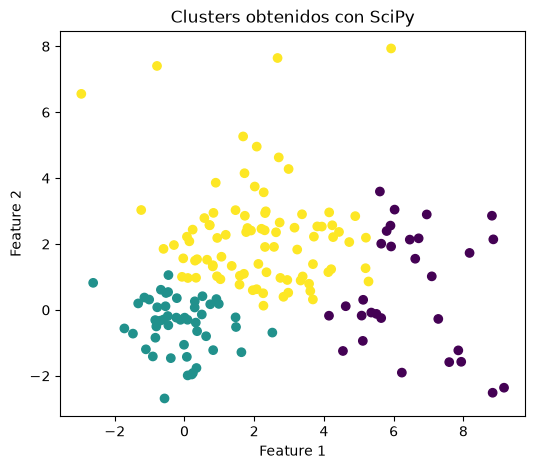

In [33]:
# Podemos “cortar” el dendrograma en un nivel para formar clusters
clusters_scipy = fcluster(Z, t=3, criterion='maxclust')

plt.figure(figsize=(6, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=clusters_scipy, cmap='viridis')
plt.title("Clusters obtenidos con SciPy")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


Hacemos lo mismo pero ahora con la función [AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) de Scikit-learn.

Por defecto, Scikit-learn utiliza la distancia euclidiana y el método de linkage `ward`.

A diferencia de scipy, esta biblioteca necesita el número de clusters como parámetro.
Calcula los clusters de forma jerárquica de la misma manera, pero "corta" cuando llega a la cantidad de clusters indicados.


In [34]:
from sklearn.cluster import AgglomerativeClustering

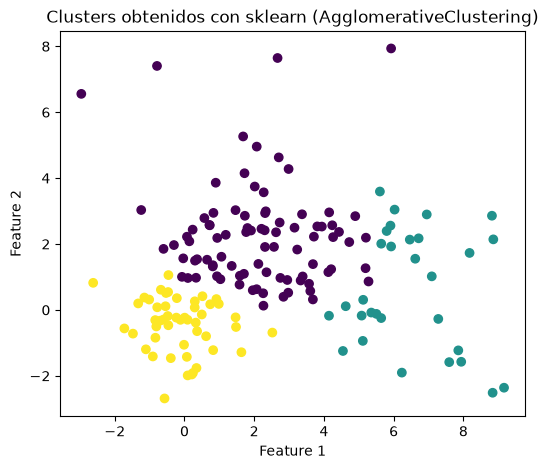

In [35]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters_sklearn = model.fit_predict(X_blobs)

plt.figure(figsize=(6, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=clusters_sklearn, cmap='viridis')
plt.title("Clusters obtenidos con sklearn (AgglomerativeClustering)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Volviendo al dataset de los clientes de un Mall, veamos de obtener el cluster usando hierarchical clustering. Veamos primero el dendrograma:

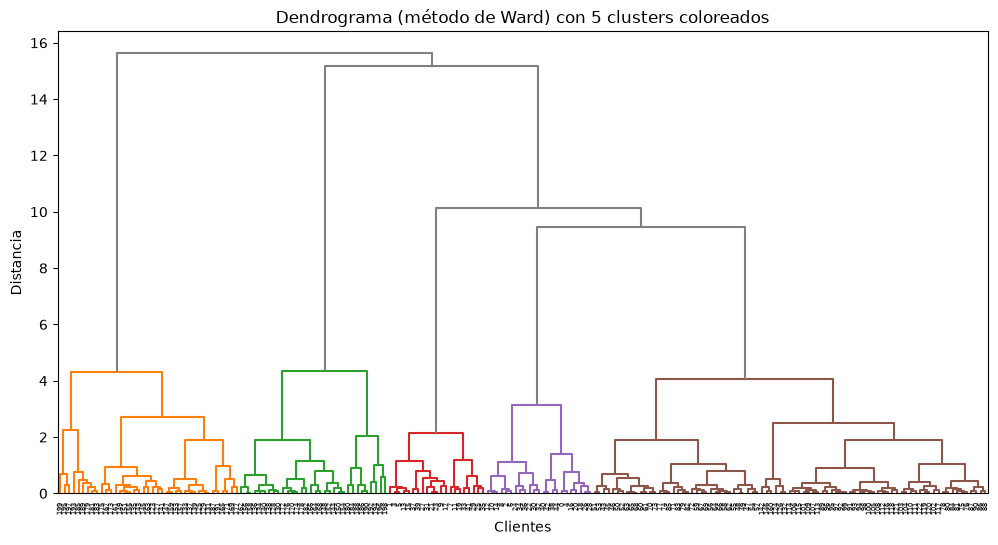

In [36]:
# Calculamos el linkage
Z = linkage(scaled_x, method='ward')

# Dibujamos el dendrograma con 5 clusters coloreados
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=Z[-(4), 2], above_threshold_color='gray')
plt.title("Dendrograma (método de Ward) con 5 clusters coloreados")
plt.xlabel("Clientes")
plt.ylabel("Distancia")
plt.show()

Usamos `AgglomerativeClustering`:

In [37]:
model = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = model.fit_predict(scaled_x)

In [38]:
df['Cluster (Hierarchical)'] = y_hc

categories_hc = {
    2: "Standard",
    1: "Spender",
    0: "Conservative",
    4: "Cautious",
    3: "Careless"
}

df["Client category (Hierarchical)"] = \
    df['Cluster (Hierarchical)'].replace(categories_hc)

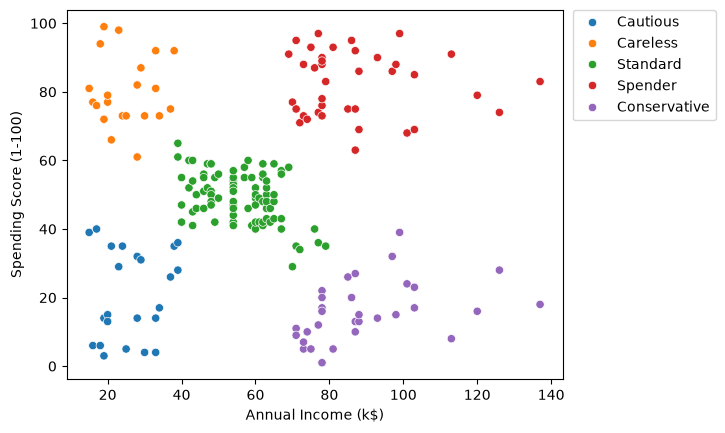

In [39]:
sns.scatterplot(data=df, 
                x="Annual Income (k$)", 
                y="Spending Score (1-100)", 
                hue="Client category (Hierarchical)")
                
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0);

Grafiquemos los clusters obtenidos usando los 3 métodos:

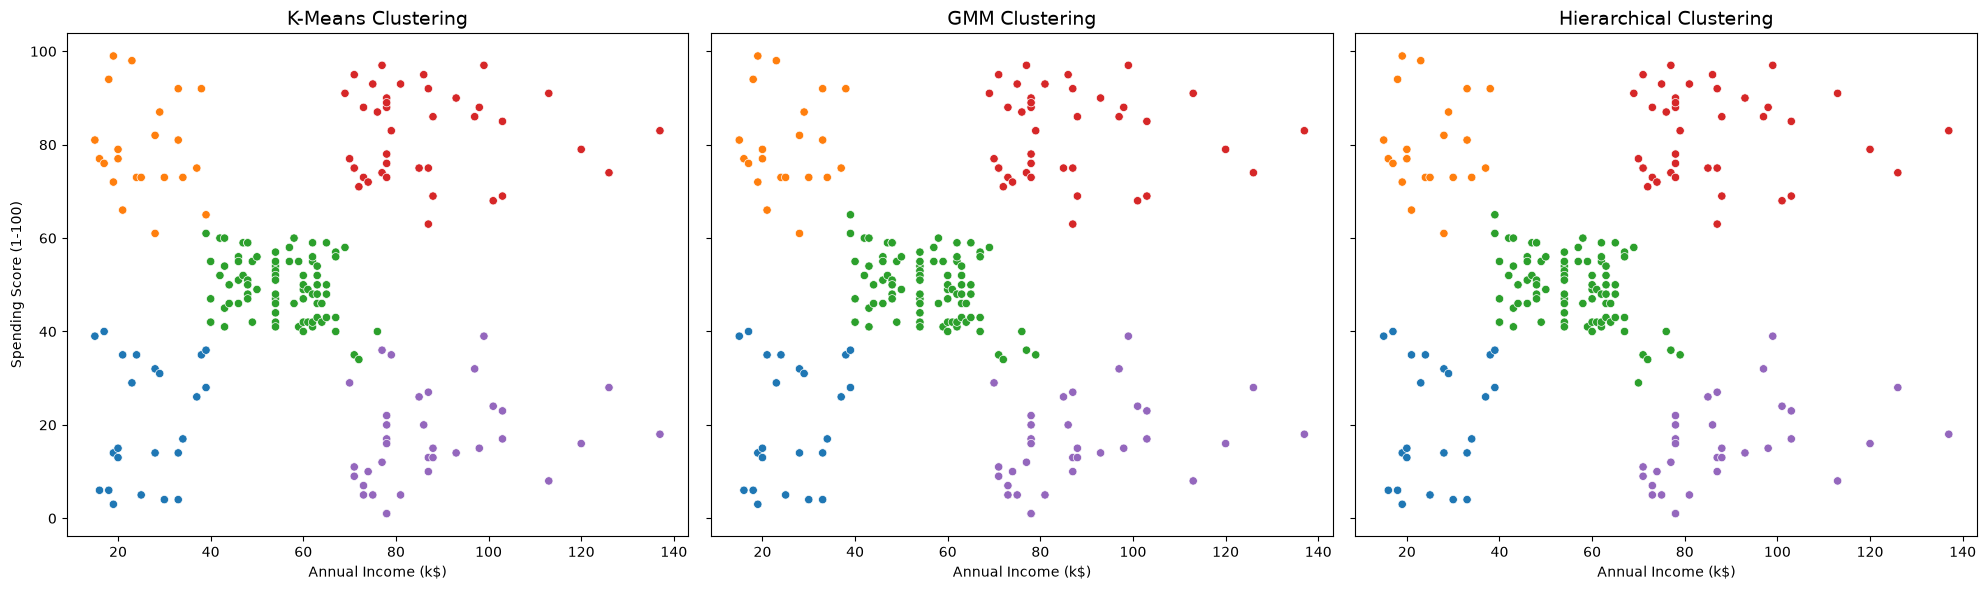

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

# --- 1. K-Means Clustering ---
sns.scatterplot(data=df, 
                x="Annual Income (k$)", 
                y="Spending Score (1-100)", 
                hue="Client category (kmeans)",
                ax=axes[0],
                legend=False)
axes[0].set_title("K-Means Clustering", fontsize=14)

# --- 2. GMM Clustering ---
sns.scatterplot(data=df, 
                x="Annual Income (k$)", 
                y="Spending Score (1-100)", 
                hue="Client category (gmm)",
                ax=axes[1],
                legend=False)
axes[1].set_title("GMM Clustering", fontsize=14)

# --- 3. Hierarchical Clustering ---
sns.scatterplot(data=df, 
                x="Annual Income (k$)", 
                y="Spending Score (1-100)", 
                hue="Client category (Hierarchical)",
                ax=axes[2],
                legend=False)
axes[2].set_title("Hierarchical Clustering", fontsize=14)

plt.tight_layout() 
plt.show()

---
Por último, se deja el enlace de [SKlearn](https://scikit-learn.org/stable/modules/clustering.html) que menciona todo sus algoritmos de clustering, con casos de usos y escalabilidad